# Assignment 3

In [89]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor, transforms
import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import json
import pandas as pd

In [19]:
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Torch version: 2.9.1+cu126
CUDA version: 12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti
Using device: cuda


# 1. Loading dataset

### Loading CIFAR-10 dataset

In [20]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [21]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

### Split dataset in train and validation set - 80/20

In [22]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

In [23]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [24]:
print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

40000
10000
10000


# 2. Three model architectures

### Baseline Lenet-5

In [25]:
class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()
    
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

### Lenet filters added

In [26]:
class LeNet5_Filters(nn.Module):

    def __init__(self):
        super().__init__()

        #increase the number of filters in the convolutional layers to 32 and 64 respectively
        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

### Lenet filters + dropout

In [ ]:
class LeNet5_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        #dropout layer with 0.5 dropout rate
        self.dropout = nn.Dropout(0.5)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        #apply dropout after the first two fully connected layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        x = self.fc3(x)

        return x # cross entropy loss already applies log-softmax internally

# 3. Train models

In [28]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False
        
        self.best_weights = None

    def __call__(self, val_loss, model):
        
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            
            # store best weights in memory
            self.best_weights = model.state_dict()
        
        else:
            self.counter += 1
            
            if self.counter >= self.patience:
                self.early_stop = True

In [29]:
criterion = nn.CrossEntropyLoss()

def train_epoch(model, train_loader, criterion, optimizer, device='cpu'):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total


def validate(model, val_loader, criterion, device='cpu'):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total

In [59]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=70, use_early_stopping=True, patience=5):
    
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    model.to(device)
    
    if use_early_stopping:
        early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        # Training and validation for this epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # Early stopping check
        if use_early_stopping:
            early_stopping(val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered!")
                break

    # Restore best model weights if early stopping was used
    if use_early_stopping and early_stopping.best_weights is not None:
        model.load_state_dict(early_stopping.best_weights)

    history = {
        "train_loss": train_losses,
        "train_acc": train_accuracies,
        "val_loss": val_losses,
        "val_acc": val_accuracies
    }

    return model, history

In [31]:
import os
import json
import torch

models = {
    "CIFAR10_lenet": LeNet5(),
    "CIFAR10_model1": LeNet5_Filters(),
    "CIFAR10_model2": LeNet5_Dropout()
}

history = {}

# create folders
os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_history", exist_ok=True)

for name, model in models.items():
    print(f"\nTraining {name}")

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, hist = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=70
    )

    # save history in Python dict
    history[name] = hist

    # save model weights
    torch.save(trained_model.state_dict(), f"saved_models/{name}.pth")

    # save per-model history as JSON
    with open(f"saved_history/{name}_history.json", "w") as f:
        json.dump(hist, f, indent=4)

# save all histories together in one JSON file
with open("saved_history/all_histories.json", "w") as f:
    json.dump(history, f, indent=4)


Training CIFAR10_lenet
Epoch 1/70 | Train Loss: 1.6520 | Train Acc: 0.4001 | Val Loss: 1.4847 | Val Acc: 0.4611
Epoch 2/70 | Train Loss: 1.3896 | Train Acc: 0.4986 | Val Loss: 1.3400 | Val Acc: 0.5154
Epoch 3/70 | Train Loss: 1.2794 | Train Acc: 0.5435 | Val Loss: 1.2960 | Val Acc: 0.5411
Epoch 4/70 | Train Loss: 1.1941 | Train Acc: 0.5761 | Val Loss: 1.2336 | Val Acc: 0.5704
Epoch 5/70 | Train Loss: 1.1277 | Train Acc: 0.6002 | Val Loss: 1.2208 | Val Acc: 0.5659
Epoch 6/70 | Train Loss: 1.0722 | Train Acc: 0.6194 | Val Loss: 1.2102 | Val Acc: 0.5762
Epoch 7/70 | Train Loss: 1.0224 | Train Acc: 0.6365 | Val Loss: 1.2003 | Val Acc: 0.5828
Epoch 8/70 | Train Loss: 0.9781 | Train Acc: 0.6512 | Val Loss: 1.2232 | Val Acc: 0.5763
Epoch 9/70 | Train Loss: 0.9343 | Train Acc: 0.6695 | Val Loss: 1.2209 | Val Acc: 0.5832
Epoch 10/70 | Train Loss: 0.8984 | Train Acc: 0.6808 | Val Loss: 1.2094 | Val Acc: 0.5923
Epoch 11/70 | Train Loss: 0.8597 | Train Acc: 0.6948 | Val Loss: 1.2441 | Val Acc: 0.

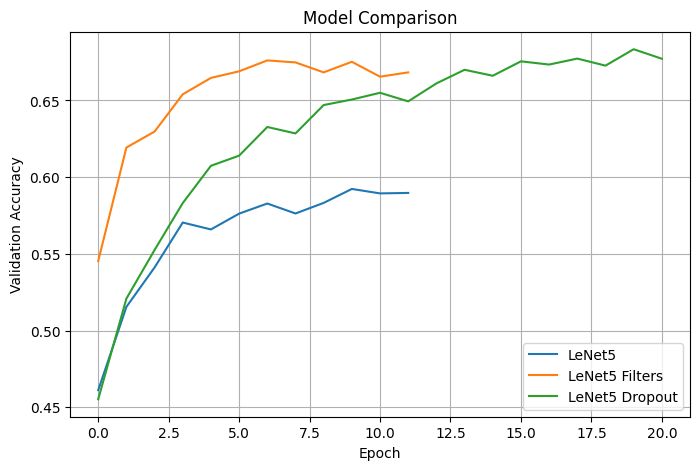

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history['CIFAR10_lenet']['val_acc'], label="LeNet5")
plt.plot(history['CIFAR10_model1']['val_acc'], label="LeNet5 Filters")
plt.plot(history['CIFAR10_model2']['val_acc'], label="LeNet5 Dropout")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

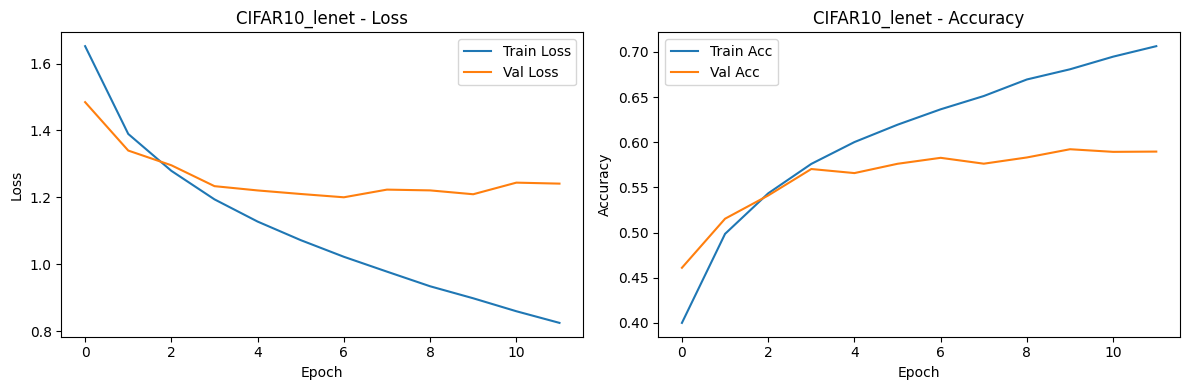

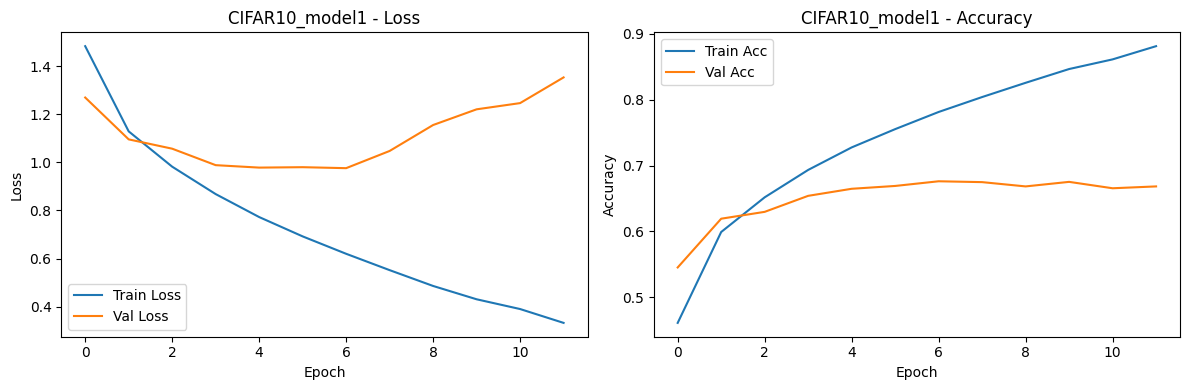

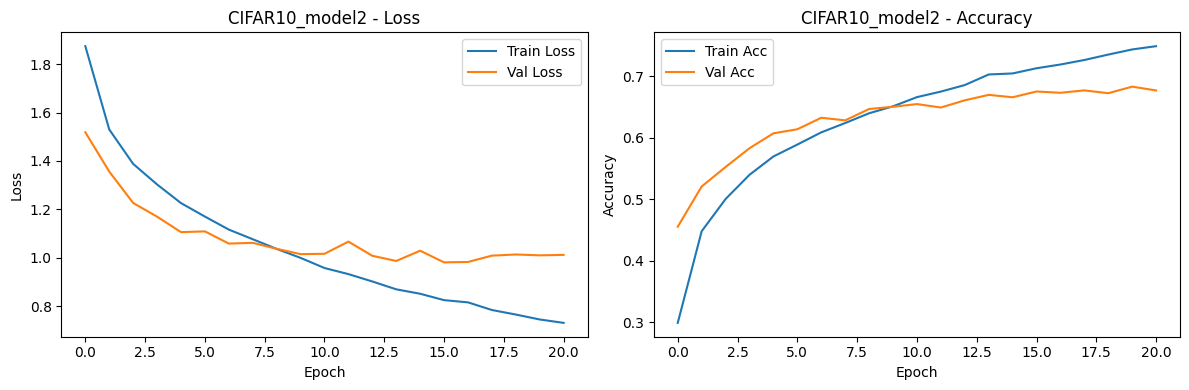

In [33]:
for model_name, data in history.items():
    plt.figure(figsize=(12, 4))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(data['train_loss'], label='Train Loss')
    plt.plot(data['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(data['train_acc'], label='Train Acc')
    plt.plot(data['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 4. Choose best architecture and load CIFAR-100

### LeNet5_Filters is the best architecture

In [34]:
best_model_name = max(history, key=lambda x: max(history[x]['val_acc']))
print("Best architecture:", best_model_name)

Best architecture: CIFAR10_model2


### Loading CIFAR100 dataset

In [35]:
train_data = datasets.CIFAR100(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [36]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader_100 = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_100 = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [37]:
class CIFAR100_Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)   # changed from 10 to 20

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [38]:
CIFAR100_model = CIFAR100_Model().to(device)

optimizer = torch.optim.Adam(CIFAR100_model.parameters(), lr=0.001)

CIFAR100_model, history_100 = train_model(
    CIFAR100_model,
    train_loader_100,
    val_loader_100,
    criterion,
    optimizer,
    device,
    epochs=70
)

torch.save(CIFAR100_model.state_dict(), f"saved_models/CIFAR100_model.pth")

# save all histories together in one JSON file
with open("saved_history/CIFAR100_model.json", "w") as f:
    json.dump(history_100, f, indent=4)


Epoch 1/70 | Train Loss: 1.6360 | Train Acc: 0.4037 | Val Loss: 1.3147 | Val Acc: 0.5269
Epoch 2/70 | Train Loss: 1.2641 | Train Acc: 0.5484 | Val Loss: 1.1898 | Val Acc: 0.5786
Epoch 3/70 | Train Loss: 1.1064 | Train Acc: 0.6048 | Val Loss: 1.1591 | Val Acc: 0.5917
Epoch 4/70 | Train Loss: 1.0017 | Train Acc: 0.6474 | Val Loss: 1.0918 | Val Acc: 0.6216
Epoch 5/70 | Train Loss: 0.9132 | Train Acc: 0.6762 | Val Loss: 1.0261 | Val Acc: 0.6515
Epoch 6/70 | Train Loss: 0.8461 | Train Acc: 0.7010 | Val Loss: 1.0363 | Val Acc: 0.6462
Epoch 7/70 | Train Loss: 0.7792 | Train Acc: 0.7254 | Val Loss: 1.0880 | Val Acc: 0.6361
Epoch 8/70 | Train Loss: 0.7238 | Train Acc: 0.7443 | Val Loss: 1.0721 | Val Acc: 0.6500
Epoch 9/70 | Train Loss: 0.6612 | Train Acc: 0.7650 | Val Loss: 1.0859 | Val Acc: 0.6570
Epoch 10/70 | Train Loss: 0.6043 | Train Acc: 0.7858 | Val Loss: 1.1650 | Val Acc: 0.6438
Early stopping triggered!


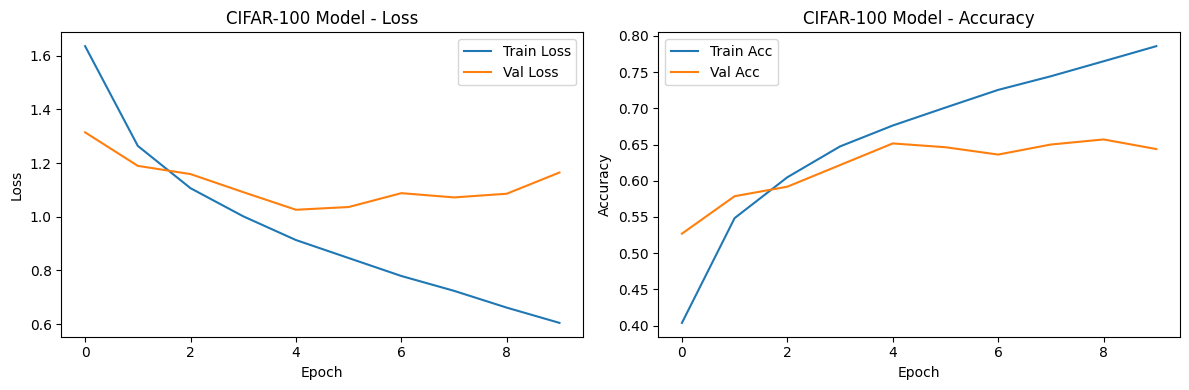

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_100['train_loss'], label='Train Loss')
plt.plot(history_100['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CIFAR-100 Model - Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_100['train_acc'], label='Train Acc')
plt.plot(history_100['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CIFAR-100 Model - Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 5. Use CIFAR100_model and change layer.

### Layer back to 10 outputs. Keep weights the same. 

In [40]:
import copy
import torch
import torch.nn as nn

# Start from the trained CIFAR-100 model
CIFAR10_pretrained = copy.deepcopy(CIFAR100_model)

# Replace only the final layer: 20 -> 10 outputs
CIFAR10_pretrained.fc3 = nn.Linear(84, 10)

# Initialize the new last layer
nn.init.kaiming_uniform_(CIFAR10_pretrained.fc3.weight, nonlinearity='relu')
if CIFAR10_pretrained.fc3.bias is not None:
    nn.init.zeros_(CIFAR10_pretrained.fc3.bias)

# Move to device
CIFAR10_pretrained = CIFAR10_pretrained.to(device)

# Fine-tune with half the original learning rate
optimizer_pretrained = torch.optim.Adam(CIFAR10_pretrained.parameters(), lr=0.0005)

# Train on CIFAR-10
CIFAR10_pretrained, history_pretrained = train_model(
    CIFAR10_pretrained,
    train_loader,
    val_loader,
    criterion,
    optimizer_pretrained,
    device,
    epochs=70
)

torch.save(CIFAR10_pretrained.state_dict(), f"saved_models/CIFAR10_pretrained.pth")

# save all histories together in one JSON file
with open("saved_history/CIFAR10_pretrained.json", "w") as f:
    json.dump(history_pretrained, f, indent=4)




Epoch 1/70 | Train Loss: 1.0405 | Train Acc: 0.6434 | Val Loss: 1.0451 | Val Acc: 0.6563
Epoch 2/70 | Train Loss: 0.6524 | Train Acc: 0.7775 | Val Loss: 1.0317 | Val Acc: 0.6718
Epoch 3/70 | Train Loss: 0.5652 | Train Acc: 0.8059 | Val Loss: 1.0473 | Val Acc: 0.6724
Epoch 4/70 | Train Loss: 0.5019 | Train Acc: 0.8286 | Val Loss: 1.0905 | Val Acc: 0.6725
Epoch 5/70 | Train Loss: 0.4465 | Train Acc: 0.8446 | Val Loss: 1.1508 | Val Acc: 0.6717
Epoch 6/70 | Train Loss: 0.3966 | Train Acc: 0.8644 | Val Loss: 1.2344 | Val Acc: 0.6624
Epoch 7/70 | Train Loss: 0.3514 | Train Acc: 0.8799 | Val Loss: 1.2729 | Val Acc: 0.6680
Early stopping triggered!


# 6. Compare CIFAR-10 model and CIFAR10_pretrained model on test set. 

### Evaluate code

In [41]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def evaluate_on_test(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm

### Evaluate both models

Replace best_model with whichever of your three CIFAR-10 models had the best validation performance.

In [42]:
best_model = models["CIFAR10_model1"]   # example, change if needed

best_test_acc, best_cm = evaluate_on_test(best_model, test_loader, device)
pretrained_test_acc, pretrained_cm = evaluate_on_test(CIFAR10_pretrained, test_loader, device)

print(f"Best CIFAR-10 model test accuracy: {best_test_acc:.4f}")
print(f"CIFAR10_pretrained test accuracy: {pretrained_test_acc:.4f}")

Best CIFAR-10 model test accuracy: 0.6604
CIFAR10_pretrained test accuracy: 0.6668


### Plot Confusion Matrices

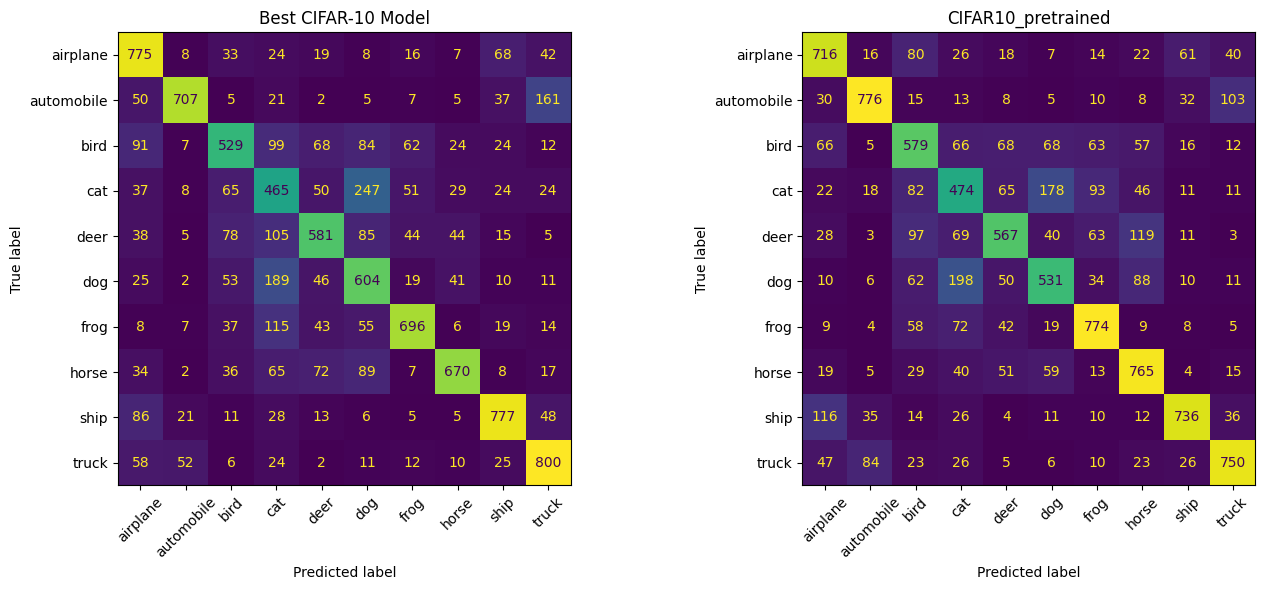

In [43]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=class_names)
disp1.plot(ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title("Best CIFAR-10 Model")

disp2 = ConfusionMatrixDisplay(confusion_matrix=pretrained_cm, display_labels=class_names)
disp2.plot(ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title("CIFAR10_pretrained")

plt.tight_layout()
plt.show()

### Report results in table

In [44]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Best CIFAR-10 model", "CIFAR10_pretrained"],
    "Test Accuracy": [best_test_acc, pretrained_test_acc]
})

print(results_df)

                 Model  Test Accuracy
0  Best CIFAR-10 model         0.6604
1   CIFAR10_pretrained         0.6668


# 7. Choices 

### Choice 1 - Decrease learning rate

In [96]:
def step_lr_decay(initial_lr, epoch, step_size=5, decay_factor=0.5):
    return initial_lr * (decay_factor ** (epoch // step_size))

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LeNet5_Dropout().to(device)

def train_model2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=70,
    use_scheduler=False,
    initial_lr=0.001,
    model_save_path="saved_models/model.pth",
    history_save_path="saved_history/history.json",
    save_best_only=True
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    lr_history = []

    best_val_acc = 0.0

    model.to(device)

    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    os.makedirs(os.path.dirname(history_save_path), exist_ok=True)

    for epoch in range(epochs):

        if use_scheduler:
            lr = step_lr_decay(initial_lr, epoch)
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
        else:
            lr = optimizer.param_groups[0]["lr"]

        lr_history.append(lr)

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"LR: {lr:.6f} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        history = {
            "train_loss": train_losses,
            "train_acc": train_accuracies,
            "val_loss": val_losses,
            "val_acc": val_accuracies,
            "lr_history": lr_history
        }

        with open(history_save_path, "w") as f:
            json.dump(history, f, indent=4)

        if save_best_only:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), model_save_path)
                print(f"Best model saved at epoch {epoch+1} with val_acc={val_acc:.4f}")
        else:
            epoch_model_path = model_save_path.replace(".pth", f"_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), epoch_model_path)

    return model, history

In [98]:
model = LeNet5_Dropout().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model_base, hist_base = train_model2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    use_scheduler=False,
    model_save_path="saved_models/choice1_model_base.pth",
    history_save_path="saved_history/choice1_hist_base.json",
    save_best_only=True
)


Epoch 1/70 | LR: 0.001000 | Train Loss: 1.8970 | Train Acc: 0.2945 | Val Loss: 1.5449 | Val Acc: 0.4125
Best model saved at epoch 1 with val_acc=0.4125
Epoch 2/70 | LR: 0.001000 | Train Loss: 1.5387 | Train Acc: 0.4442 | Val Loss: 1.2978 | Val Acc: 0.5317
Best model saved at epoch 2 with val_acc=0.5317
Epoch 3/70 | LR: 0.001000 | Train Loss: 1.3889 | Train Acc: 0.5100 | Val Loss: 1.2273 | Val Acc: 0.5678
Best model saved at epoch 3 with val_acc=0.5678
Epoch 4/70 | LR: 0.001000 | Train Loss: 1.3056 | Train Acc: 0.5413 | Val Loss: 1.1822 | Val Acc: 0.5793
Best model saved at epoch 4 with val_acc=0.5793
Epoch 5/70 | LR: 0.001000 | Train Loss: 1.2226 | Train Acc: 0.5723 | Val Loss: 1.1414 | Val Acc: 0.6019
Best model saved at epoch 5 with val_acc=0.6019
Epoch 6/70 | LR: 0.001000 | Train Loss: 1.1633 | Train Acc: 0.5971 | Val Loss: 1.1237 | Val Acc: 0.6106
Best model saved at epoch 6 with val_acc=0.6106
Epoch 7/70 | LR: 0.001000 | Train Loss: 1.1134 | Train Acc: 0.6131 | Val Loss: 1.0676 | 

In [99]:
model = LeNet5_Dropout().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model_sched, hist_sched = train_model2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=70,
    use_scheduler=True,
    initial_lr=0.001,
    model_save_path="saved_models/choice1_model_sched.pth",
    history_save_path="saved_history/choice1_hist_sched.json",
    save_best_only=True
)

Epoch 1/70 | LR: 0.001000 | Train Loss: 1.8866 | Train Acc: 0.2894 | Val Loss: 1.5176 | Val Acc: 0.4333
Best model saved at epoch 1 with val_acc=0.4333
Epoch 2/70 | LR: 0.001000 | Train Loss: 1.5130 | Train Acc: 0.4507 | Val Loss: 1.2895 | Val Acc: 0.5273
Best model saved at epoch 2 with val_acc=0.5273
Epoch 3/70 | LR: 0.001000 | Train Loss: 1.3634 | Train Acc: 0.5150 | Val Loss: 1.1828 | Val Acc: 0.5786
Best model saved at epoch 3 with val_acc=0.5786
Epoch 4/70 | LR: 0.001000 | Train Loss: 1.2713 | Train Acc: 0.5552 | Val Loss: 1.1295 | Val Acc: 0.6084
Best model saved at epoch 4 with val_acc=0.6084
Epoch 5/70 | LR: 0.001000 | Train Loss: 1.1981 | Train Acc: 0.5784 | Val Loss: 1.1285 | Val Acc: 0.5953
Epoch 6/70 | LR: 0.000500 | Train Loss: 1.0763 | Train Acc: 0.6248 | Val Loss: 1.0592 | Val Acc: 0.6308
Best model saved at epoch 6 with val_acc=0.6308
Epoch 7/70 | LR: 0.000500 | Train Loss: 1.0294 | Train Acc: 0.6436 | Val Loss: 0.9969 | Val Acc: 0.6509
Best model saved at epoch 7 with

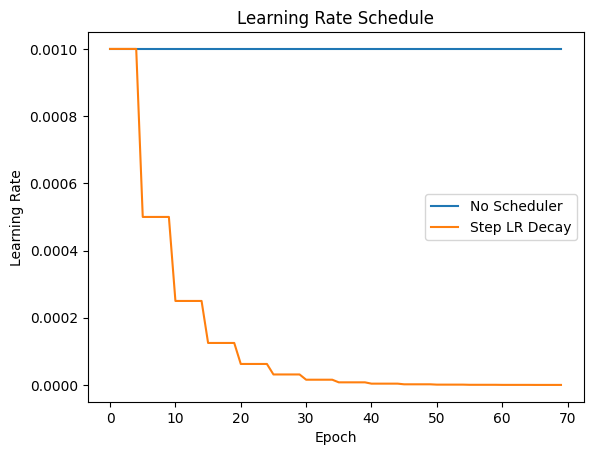

In [100]:
plt.plot(hist_base["lr_history"], label="No Scheduler")
plt.plot(hist_sched["lr_history"], label="Step LR Decay")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()

=== Final Comparison ===
Baseline   -> Train Acc: 0.8595, Val Acc: 0.6794, Train Loss: 0.4125, Val Loss: 1.5128
Scheduler  -> Train Acc: 0.8016, Val Acc: 0.6961, Train Loss: 0.5700, Val Loss: 1.0064

=== Best Validation Accuracy ===
Baseline   -> Best Val Acc: 0.6867 at epoch 66
Scheduler  -> Best Val Acc: 0.6971 at epoch 35


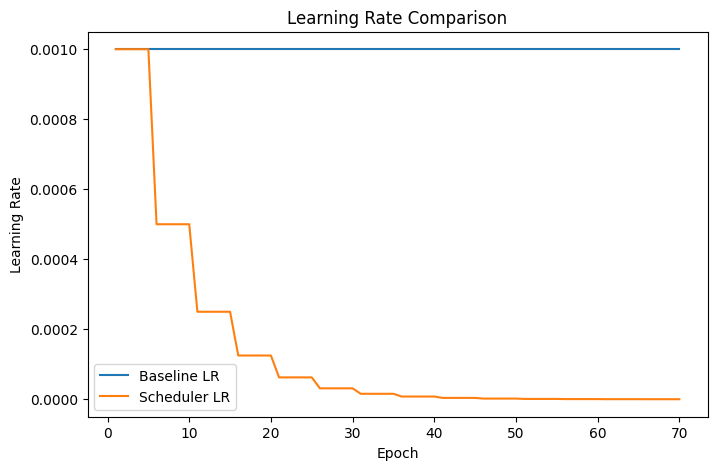

In [101]:
with open("saved_history/choice1_hist_base.json", "r") as f:
    hist_base = json.load(f)

with open("saved_history/choice1_hist_sched.json", "r") as f:
    hist_sched = json.load(f)

epochs_base = range(1, len(hist_base["train_loss"]) + 1)
epochs_sched = range(1, len(hist_sched["train_loss"]) + 1)

# final metric summary
print("=== Final Comparison ===")
print(f"Baseline   -> Train Acc: {hist_base['train_acc'][-1]:.4f}, Val Acc: {hist_base['val_acc'][-1]:.4f}, "
      f"Train Loss: {hist_base['train_loss'][-1]:.4f}, Val Loss: {hist_base['val_loss'][-1]:.4f}")

print(f"Scheduler  -> Train Acc: {hist_sched['train_acc'][-1]:.4f}, Val Acc: {hist_sched['val_acc'][-1]:.4f}, "
      f"Train Loss: {hist_sched['train_loss'][-1]:.4f}, Val Loss: {hist_sched['val_loss'][-1]:.4f}")

# best validation accuracy
best_base_acc = max(hist_base["val_acc"])
best_sched_acc = max(hist_sched["val_acc"])

best_base_epoch = hist_base["val_acc"].index(best_base_acc) + 1
best_sched_epoch = hist_sched["val_acc"].index(best_sched_acc) + 1

print("\n=== Best Validation Accuracy ===")
print(f"Baseline   -> Best Val Acc: {best_base_acc:.4f} at epoch {best_base_epoch}")
print(f"Scheduler  -> Best Val Acc: {best_sched_acc:.4f} at epoch {best_sched_epoch}")


# learning rate comparison
plt.figure(figsize=(8, 5))
plt.plot(epochs_base, hist_base["lr_history"], label="Baseline LR")
plt.plot(epochs_sched, hist_sched["lr_history"], label="Scheduler LR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [102]:
print("Final Baseline Val Acc:", hist_base["val_acc"][-1])
print("Final Scheduler Val Acc:", hist_sched["val_acc"][-1])

print("Best Baseline Val Acc:", max(hist_base["val_acc"]))
print("Best Scheduler Val Acc:", max(hist_sched["val_acc"]))

Final Baseline Val Acc: 0.6794
Final Scheduler Val Acc: 0.6961
Best Baseline Val Acc: 0.6867
Best Scheduler Val Acc: 0.6971


### Choice 2 - k-fold cross-validation

Load CIFAR_10 training set

In [50]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

c:\Users\matth\anaconda3\envs\CV_clean\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


K-fold training function

In [60]:
import numpy as np
import torch
import json
import os
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader

def k_fold_cross_validation(
    model_class,
    dataset,
    criterion,
    device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001,
    random_state=42
):
    os.makedirs("saved_models", exist_ok=True)
    os.makedirs("saved_history", exist_ok=True)

    kfold = KFold(n_splits=k, shuffle=True, random_state=random_state)

    fold_results = []
    fold_histories = []

    indices = np.arange(len(dataset))

    for fold, (train_idx, val_idx) in enumerate(kfold.split(indices)):
        print(f"\n===== Fold {fold+1}/{k} =====")

        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            device,
            epochs=epochs,
            use_early_stopping=False
        )

        best_val_acc = max(history["val_acc"])
        best_val_loss = min(history["val_loss"])

        fold_results.append({
            "fold": fold + 1,
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss
        })

        fold_histories.append(history)

        print(
            f"Fold {fold+1} finished | "
            f"Best Val Acc: {best_val_acc:.4f} | "
            f"Best Val Loss: {best_val_loss:.4f}"
        )

        # save model
        torch.save(model.state_dict(), f"saved_models/choice_2_model_fold{fold+1}.pth")

        # save history
        json.dump(
            {key: [float(x) for x in value] for key, value in history.items()},
            open(f"saved_history/choice_2_history_fold{fold+1}.json", "w")
        )

    # save summary results
    json.dump(fold_results, open("saved_history/choice_2_fold_results.json", "w"), indent=4)

    json.dump(
        [{key: [float(x) for x in value] for key, value in h.items()} for h in fold_histories],
        open("saved_history/choice_2_all_fold_histories.json", "w")
    )

    return fold_results, fold_histories

Run 5-fold cross-validation

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

cv_results, cv_histories = k_fold_cross_validation(
    model_class=LeNet5_Filters,
    dataset=full_train_dataset,
    criterion=criterion,
    device=device,
    k=5,
    epochs=70,
    batch_size=32,
    lr=0.001
)



===== Fold 1/5 =====
Epoch 1/70 | Train Loss: 1.5085 | Train Acc: 0.4506 | Val Loss: 1.2649 | Val Acc: 0.5460
Epoch 2/70 | Train Loss: 1.1843 | Train Acc: 0.5796 | Val Loss: 1.1522 | Val Acc: 0.5902
Epoch 3/70 | Train Loss: 1.0296 | Train Acc: 0.6354 | Val Loss: 1.0899 | Val Acc: 0.6172
Epoch 4/70 | Train Loss: 0.9270 | Train Acc: 0.6736 | Val Loss: 1.0171 | Val Acc: 0.6414
Epoch 5/70 | Train Loss: 0.8450 | Train Acc: 0.7019 | Val Loss: 0.9845 | Val Acc: 0.6548
Epoch 6/70 | Train Loss: 0.7653 | Train Acc: 0.7300 | Val Loss: 0.9629 | Val Acc: 0.6692
Epoch 7/70 | Train Loss: 0.6943 | Train Acc: 0.7550 | Val Loss: 1.0005 | Val Acc: 0.6666
Epoch 8/70 | Train Loss: 0.6307 | Train Acc: 0.7766 | Val Loss: 1.0308 | Val Acc: 0.6689
Epoch 9/70 | Train Loss: 0.5687 | Train Acc: 0.7975 | Val Loss: 1.0337 | Val Acc: 0.6624
Epoch 10/70 | Train Loss: 0.5066 | Train Acc: 0.8222 | Val Loss: 1.1437 | Val Acc: 0.6598
Epoch 11/70 | Train Loss: 0.4584 | Train Acc: 0.8349 | Val Loss: 1.1810 | Val Acc: 0.65

Summarize fold results

In [62]:
import pandas as pd

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

mean_val_acc = cv_results_df["best_val_acc"].mean()
std_val_acc = cv_results_df["best_val_acc"].std()

mean_val_loss = cv_results_df["best_val_loss"].mean()
std_val_loss = cv_results_df["best_val_loss"].std()

print(f"\nMean Best Validation Accuracy: {mean_val_acc:.4f} ± {std_val_acc:.4f}")
print(f"Mean Best Validation Loss: {mean_val_loss:.4f} ± {std_val_loss:.4f}")

   fold  best_val_acc  best_val_loss
0     1        0.6692       0.962923
1     2        0.6645       0.997750
2     3        0.6676       1.006352
3     4        0.6700       0.969075
4     5        0.6692       0.981742

Mean Best Validation Accuracy: 0.6681 ± 0.0022
Mean Best Validation Loss: 0.9836 ± 0.0184


Compare against fixed train/validation split

In [63]:
history_fixed = history["CIFAR10_model2"]

In [64]:
fixed_best_val_acc = max(history_fixed["val_acc"])
fixed_best_val_loss = min(history_fixed["val_loss"])

comparison_df = pd.DataFrame({
    "Method": ["Fixed Train/Val Split", "5-Fold Cross-Validation"],
    "Validation Accuracy": [fixed_best_val_acc, mean_val_acc],
    "Validation Loss": [fixed_best_val_loss, mean_val_loss]
})

print(comparison_df)

                    Method  Validation Accuracy  Validation Loss
0    Fixed Train/Val Split               0.6834         0.980573
1  5-Fold Cross-Validation               0.6681         0.983568


Plot validation accuracy per fold

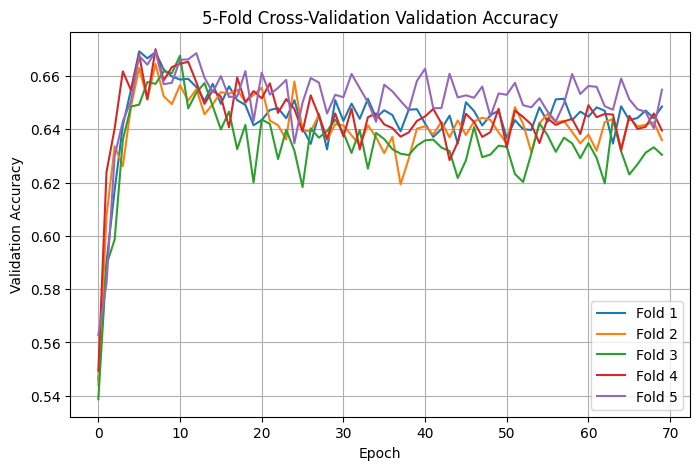

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for i, hist in enumerate(cv_histories):
    plt.plot(hist["val_acc"], label=f"Fold {i+1}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Cross-Validation Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Plot average validation accuracy across folds

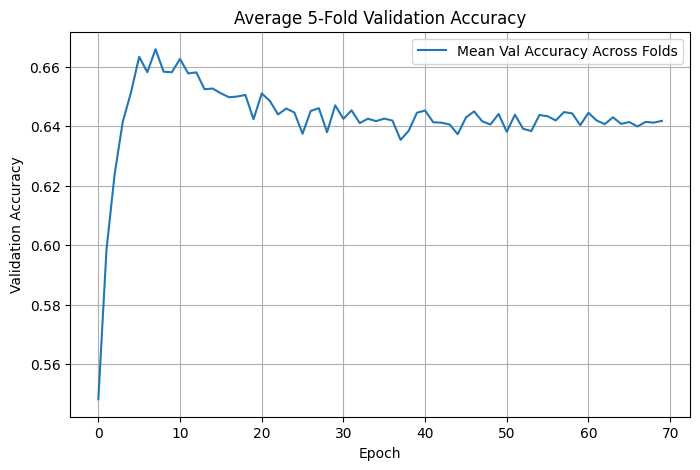

In [66]:
val_acc_matrix = np.array([hist["val_acc"] for hist in cv_histories])
mean_val_acc_per_epoch = val_acc_matrix.mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(mean_val_acc_per_epoch, label="Mean Val Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Average 5-Fold Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Full minimal version in one block, if the above code doesn't work

### Choice 6 - t-SNE

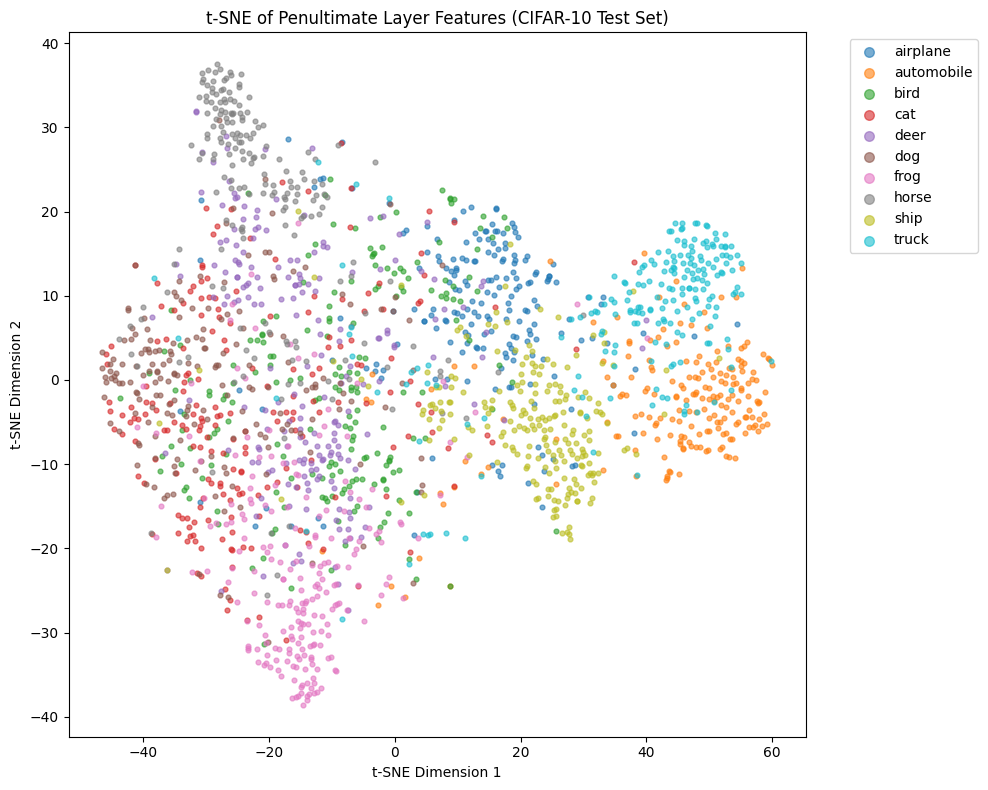

In [69]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def extract_penultimate_features_subset(model, data_loader, device, max_samples=2000):
    model.eval()
    features = []
    labels_list = []
    collected = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            x = model.pool(F.relu(model.conv1(images)))
            x = model.pool(F.relu(model.conv2(x)))
            x = torch.flatten(x, 1)
            x = F.relu(model.fc1(x))
            x = F.relu(model.fc2(x))

            batch_features = x.cpu().numpy()
            batch_labels = labels.cpu().numpy()

            remaining = max_samples - collected
            if remaining <= 0:
                break

            batch_features = batch_features[:remaining]
            batch_labels = batch_labels[:remaining]

            features.append(batch_features)
            labels_list.append(batch_labels)
            collected += len(batch_features)

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return features, labels

# Choose one of your best models
chosen_model = best_model

features, labels = extract_penultimate_features_subset(
    chosen_model, test_loader, device, max_samples=2000
)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

features_2d = tsne.fit_transform(features)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10, 8))

for class_idx, class_name in enumerate(class_names):
    idxs = labels == class_idx
    plt.scatter(
        features_2d[idxs, 0],
        features_2d[idxs, 1],
        label=class_name,
        alpha=0.6,
        s=12
    )

plt.title("t-SNE of Penultimate Layer Features (CIFAR-10 Test Set)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Choice 3 - Evolutionary Search

In [70]:
search_space = {
    "optimizer": ["adam", "sgd", "rmsprop"],
    "lr": [0.001, 0.0005, 0.0001],
    "weight_decay": [0.0, 1e-4],
    "batch_size": [32, 64]  
}

In [71]:
import random

def random_individual():
    return {
        "optimizer": random.choice(search_space["optimizer"]),
        "lr": random.choice(search_space["lr"]),
        "weight_decay": random.choice(search_space["weight_decay"]),
        "batch_size": random.choice(search_space["batch_size"])
    }

def mutate(individual):
    new_ind = individual.copy()

    key = random.choice(list(search_space.keys()))
    new_ind[key] = random.choice(search_space[key])

    return new_ind

In [72]:
def get_optimizer(name, model, lr, weight_decay):

    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    elif name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    elif name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

In [90]:
def evaluate(individual):

    # Create dataloaders with chosen batch size
    train_loader_local = DataLoader(train_dataset, batch_size=individual["batch_size"], shuffle=True)
    val_loader_local = DataLoader(val_dataset, batch_size=individual["batch_size"], shuffle=False)

    model = LeNet5().to(device)

    optimizer = get_optimizer(
        individual["optimizer"],
        model,
        individual["lr"],
        individual["weight_decay"]
    )

    model, hist = train_model2(
        model,
        train_loader_local,
        val_loader_local,
        criterion,
        optimizer,
        device,
        epochs=15,   # fewer epochs
        use_scheduler=False,
        initial_lr=individual["lr"]
    )

    return max(hist["val_acc"])

In [ ]:
population_size = 6
generations = 3

population = [random_individual() for _ in range(population_size)]

results = []

for gen in range(generations):

    print(f"\nGeneration {gen+1}")

    scored_population = []

    for ind in population:

        acc = evaluate(ind)

        print(ind, "->", acc)

        scored_population.append((ind, acc))
        results.append({
            "optimizer": ind["optimizer"],
            "lr": ind["lr"],
            "weight_decay": ind["weight_decay"],
            "batch_size": ind["batch_size"],
            "val_acc": acc
        })

    # Sort by fitness (accuracy)
    scored_population.sort(key=lambda x: x[1], reverse=True)

    # Select top 2
    best = [scored_population[0][0], scored_population[1][0]]

    # Create new population
    population = best.copy()

    while len(population) < population_size:
        parent = random.choice(best)
        child = mutate(parent) 
        population.append(child)


Generation 1
Epoch 1/15 | LR: 0.000100 | Train Loss: 1.8580 | Train Acc: 0.3119 | Val Loss: 1.6132 | Val Acc: 0.4106
Epoch 2/15 | LR: 0.000100 | Train Loss: 1.5746 | Train Acc: 0.4299 | Val Loss: 1.5034 | Val Acc: 0.4561
Epoch 3/15 | LR: 0.000100 | Train Loss: 1.4937 | Train Acc: 0.4605 | Val Loss: 1.4553 | Val Acc: 0.4756
Epoch 4/15 | LR: 0.000100 | Train Loss: 1.4401 | Train Acc: 0.4827 | Val Loss: 1.3982 | Val Acc: 0.4995
Epoch 5/15 | LR: 0.000100 | Train Loss: 1.3993 | Train Acc: 0.4978 | Val Loss: 1.3588 | Val Acc: 0.5182
Epoch 6/15 | LR: 0.000100 | Train Loss: 1.3642 | Train Acc: 0.5122 | Val Loss: 1.3299 | Val Acc: 0.5272
Epoch 7/15 | LR: 0.000100 | Train Loss: 1.3338 | Train Acc: 0.5251 | Val Loss: 1.3040 | Val Acc: 0.5377
Epoch 8/15 | LR: 0.000100 | Train Loss: 1.3053 | Train Acc: 0.5363 | Val Loss: 1.2707 | Val Acc: 0.5516
Epoch 9/15 | LR: 0.000100 | Train Loss: 1.2811 | Train Acc: 0.5437 | Val Loss: 1.2400 | Val Acc: 0.5634
Epoch 10/15 | LR: 0.000100 | Train Loss: 1.2581 | 

KeyError: 1

In [106]:
best_result = max(results, key=lambda x: x["val_acc"])

print("\nBest configuration:")
print(best_result)


Best configuration:
{'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'val_acc': 0.77675}


In [107]:
df = pd.DataFrame(results)

df = df.drop_duplicates()

# Sort by performance
df = df.sort_values(by="val_acc", ascending=False)

print(df)

   optimizer      lr  weight_decay  batch_size   val_acc
12      adam  0.0010        0.0000          64  0.776750
10      adam  0.0010        0.0000          64  0.749375
16      adam  0.0010        0.0000          64  0.746625
15      adam  0.0010        0.0001          64  0.724250
8       adam  0.0005        0.0000          64  0.702000
9       adam  0.0005        0.0000          64  0.693500
13      adam  0.0005        0.0000          64  0.692875
6       adam  0.0005        0.0000          64  0.689125
14      adam  0.0005        0.0001          64  0.681125
5       adam  0.0005        0.0000          64  0.676875
7        sgd  0.0010        0.0000          32  0.646750
4        sgd  0.0010        0.0000          32  0.641875
1        sgd  0.0010        0.0001          64  0.616125
0       adam  0.0001        0.0000          32  0.604125
11       sgd  0.0010        0.0000          64  0.602625
3       adam  0.0001        0.0000          32  0.595375
2       adam  0.0001        0.0

In [108]:
print(df.to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lrrrr}
\toprule
optimizer & lr & weight_decay & batch_size & val_acc \\
\midrule
adam & 0.0010 & 0.0000 & 64 & 0.7768 \\
adam & 0.0010 & 0.0000 & 64 & 0.7494 \\
adam & 0.0010 & 0.0000 & 64 & 0.7466 \\
adam & 0.0010 & 0.0001 & 64 & 0.7242 \\
adam & 0.0005 & 0.0000 & 64 & 0.7020 \\
adam & 0.0005 & 0.0000 & 64 & 0.6935 \\
adam & 0.0005 & 0.0000 & 64 & 0.6929 \\
adam & 0.0005 & 0.0000 & 64 & 0.6891 \\
adam & 0.0005 & 0.0001 & 64 & 0.6811 \\
adam & 0.0005 & 0.0000 & 64 & 0.6769 \\
sgd & 0.0010 & 0.0000 & 32 & 0.6468 \\
sgd & 0.0010 & 0.0000 & 32 & 0.6419 \\
sgd & 0.0010 & 0.0001 & 64 & 0.6161 \\
adam & 0.0001 & 0.0000 & 32 & 0.6041 \\
sgd & 0.0010 & 0.0000 & 64 & 0.6026 \\
adam & 0.0001 & 0.0000 & 32 & 0.5954 \\
adam & 0.0001 & 0.0000 & 64 & 0.5680 \\
adam & 0.0001 & 0.0000 & 64 & 0.5611 \\
\bottomrule
\end{tabular}



Best configuration:
{'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'val_acc': 0.77675}

### Choice 5 - Data Augmentation

In [75]:
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

baseline

In [76]:
train_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

c:\Users\matth\anaconda3\envs\CV_clean\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


augmented only on train

In [77]:
train_dataset_aug = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform_augmented
)

In [78]:
transform_test = transforms.Compose([
    transforms.ToTensor()
])

baseline model was already trained

In [79]:
hist_baseline = history["CIFAR10_lenet"]

augmented

In [81]:
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

model_aug = LeNet5().to(device)

optimizer = torch.optim.Adam(model_aug.parameters(), lr=0.001)

model_aug, hist_aug = train_model(
    model_aug,
    train_loader_aug,
    val_loader,
    criterion,
    optimizer,
    device,
    use_early_stopping=True,
)

Epoch 1/70 | Train Loss: 1.7336 | Train Acc: 0.3655 | Val Loss: 1.4356 | Val Acc: 0.4817
Epoch 2/70 | Train Loss: 1.5213 | Train Acc: 0.4499 | Val Loss: 1.3329 | Val Acc: 0.5204
Epoch 3/70 | Train Loss: 1.4359 | Train Acc: 0.4865 | Val Loss: 1.2664 | Val Acc: 0.5447
Epoch 4/70 | Train Loss: 1.3734 | Train Acc: 0.5091 | Val Loss: 1.2177 | Val Acc: 0.5659
Epoch 5/70 | Train Loss: 1.3297 | Train Acc: 0.5239 | Val Loss: 1.1830 | Val Acc: 0.5776
Epoch 6/70 | Train Loss: 1.2995 | Train Acc: 0.5367 | Val Loss: 1.1811 | Val Acc: 0.5845
Epoch 7/70 | Train Loss: 1.2738 | Train Acc: 0.5418 | Val Loss: 1.1412 | Val Acc: 0.5954
Epoch 8/70 | Train Loss: 1.2503 | Train Acc: 0.5552 | Val Loss: 1.1108 | Val Acc: 0.5994
Epoch 9/70 | Train Loss: 1.2272 | Train Acc: 0.5620 | Val Loss: 1.0732 | Val Acc: 0.6137
Epoch 10/70 | Train Loss: 1.2098 | Train Acc: 0.5722 | Val Loss: 1.0751 | Val Acc: 0.6144
Epoch 11/70 | Train Loss: 1.1916 | Train Acc: 0.5746 | Val Loss: 1.0354 | Val Acc: 0.6311
Epoch 12/70 | Train

In [82]:
baseline_acc = max(hist_baseline["val_acc"])
aug_acc = max(hist_aug["val_acc"])

print("Baseline:", baseline_acc)
print("Augmented:", aug_acc)

Baseline: 0.5923
Augmented: 0.6636


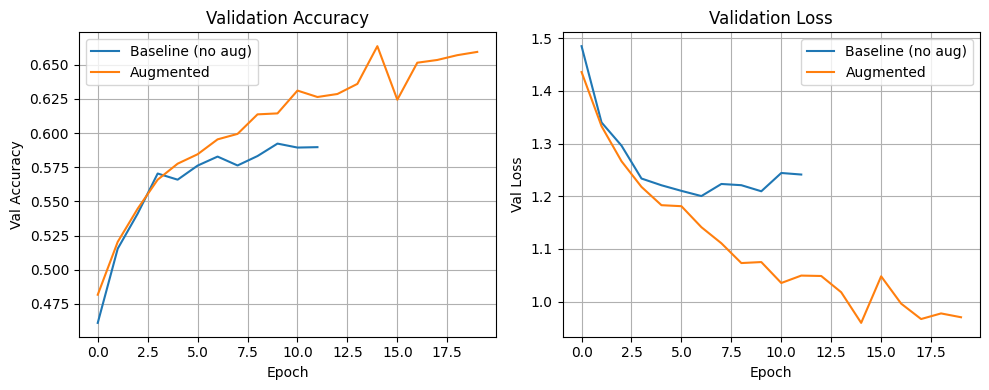

In [83]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_baseline["val_acc"], label="Baseline (no aug)")
plt.plot(hist_aug["val_acc"], label="Augmented")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_baseline["val_loss"], label="Baseline (no aug)")
plt.plot(hist_aug["val_loss"], label="Augmented")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

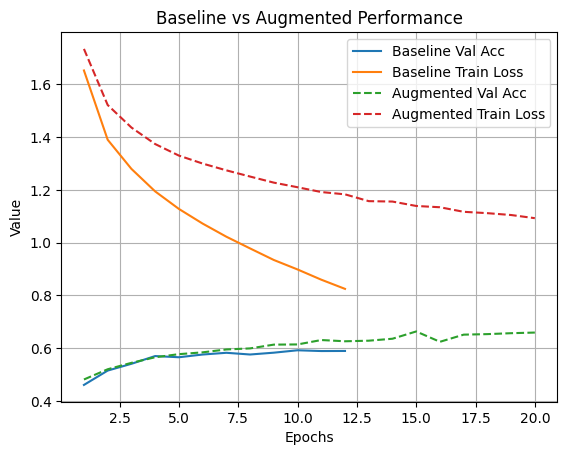

In [86]:
epochs_baseline = range(1, len(hist_baseline["val_acc"]) + 1)

epochs_aug = range(1, len(hist_aug["val_acc"]) + 1)

plt.figure()

# Baseline
plt.plot(epochs_baseline, hist_baseline["val_acc"], label="Baseline Val Acc")
plt.plot(epochs_baseline, hist_baseline["train_loss"], label="Baseline Train Loss")

# Augmented
plt.plot(epochs_aug, hist_aug["val_acc"], linestyle='--',label="Augmented Val Acc")
plt.plot(epochs_aug, hist_aug["train_loss"], linestyle='--', label="Augmented Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Baseline vs Augmented Performance")
plt.legend()
plt.grid()

plt.show()

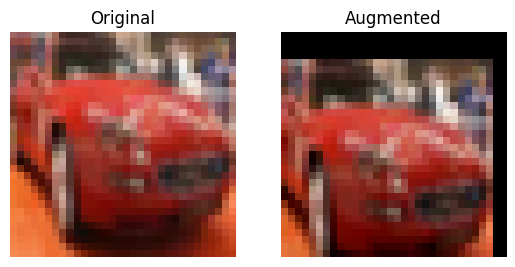

In [ ]:
def compare_original_vs_aug(original_dataset, augmented_dataset):

    img_orig, _ = original_dataset[5]
    img_aug, _ = augmented_dataset[5]

    img_orig = np.transpose(img_orig.numpy(), (1, 2, 0))
    img_aug = np.transpose(img_aug.numpy(), (1, 2, 0))

    plt.figure()

    plt.subplot(1, 2, 1)
    plt.imshow(img_orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_aug)
    plt.title("Augmented")
    plt.axis("off")

    plt.show()

compare_original_vs_aug(train_dataset, train_dataset_aug)